In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("loan_approval_data.csv")

In [3]:
df

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,NaN,Car,Semiurban,Graduate,NaN,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996.0,NaN,9092.0,Salaried,58.0,Married,0.0,557.0,0.0,0.59,5370.0,43563.0,8311.0,72.0,Personal,NaN,Not Graduate,Male,Unemployed,No
996,997.0,3279.0,6356.0,Self-employed,58.0,Married,1.0,646.0,3.0,0.19,NaN,18361.0,22563.0,12.0,Business,Urban,Graduate,Female,Government,No
997,998.0,15192.0,8433.0,Contract,48.0,Single,1.0,666.0,1.0,0.40,8581.0,41335.0,16203.0,24.0,Home,Rural,Graduate,Male,MNC,No
998,999.0,9083.0,7380.0,Unemployed,50.0,Single,1.0,748.0,3.0,0.31,13491.0,8933.0,10290.0,36.0,Personal,Urban,Graduate,Male,Private,Yes


# removing Applicant id -> we did'nt need unneccesary feature 

In [4]:
df = df.drop("Applicant_ID" , axis =1)

In [5]:
df

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,NaN,Car,Semiurban,Graduate,NaN,Private,No
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,NaN,9092.0,Salaried,58.0,Married,0.0,557.0,0.0,0.59,5370.0,43563.0,8311.0,72.0,Personal,NaN,Not Graduate,Male,Unemployed,No
996,3279.0,6356.0,Self-employed,58.0,Married,1.0,646.0,3.0,0.19,NaN,18361.0,22563.0,12.0,Business,Urban,Graduate,Female,Government,No
997,15192.0,8433.0,Contract,48.0,Single,1.0,666.0,1.0,0.40,8581.0,41335.0,16203.0,24.0,Home,Rural,Graduate,Male,MNC,No
998,9083.0,7380.0,Unemployed,50.0,Single,1.0,748.0,3.0,0.31,13491.0,8933.0,10290.0,36.0,Personal,Urban,Graduate,Male,Private,Yes


# lets start by filling null values -> NaN values filling 

In [6]:
#  selecting diffrent types of columns 
num_cols = df.select_dtypes(include=["number"]).columns
cat_cols = df.select_dtypes(include=["object"]).columns

In [7]:
num_cols

Index(['Applicant_Income', 'Coapplicant_Income', 'Age', 'Dependents',
       'Credit_Score', 'Existing_Loans', 'DTI_Ratio', 'Savings',
       'Collateral_Value', 'Loan_Amount', 'Loan_Term'],
      dtype='object')

In [8]:
cat_cols

Index(['Employment_Status', 'Marital_Status', 'Loan_Purpose', 'Property_Area',
       'Education_Level', 'Gender', 'Employer_Category', 'Loan_Approved'],
      dtype='object')

# columns selection done 


In [9]:
#  filling null values 

#  we are going to fills values using immputer from scikit learn library
from sklearn.impute import SimpleImputer
num_imp = SimpleImputer(strategy = "mean")
df[num_cols] = num_imp.fit_transform(df[num_cols])

In [10]:
df.sample(6)

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
581,9239.0,3192.0,Self-employed,39.971579,Single,0.0,553.0,2.000000,0.14,13785.0,43417.0,3010.0,84.0,Personal,Urban,Graduate,Male,Government,No
441,4502.0,2720.0,Salaried,31.000000,Married,3.0,604.0,1.950526,0.49,10695.0,40404.0,15404.0,84.0,Business,Urban,Graduate,Male,MNC,No
992,19939.0,7993.0,Unemployed,39.971579,Single,2.0,766.0,2.000000,0.28,6680.0,47037.0,2848.0,24.0,Business,Semiurban,Graduate,Male,Government,Yes
717,5812.0,9206.0,Self-employed,39.971579,Single,0.0,626.0,2.000000,0.57,7637.0,6229.0,35980.0,12.0,Car,Rural,Graduate,Male,Unemployed,No
960,18380.0,8591.0,Self-employed,29.000000,Married,2.0,786.0,4.000000,0.15,17274.0,39673.0,8543.0,72.0,NaN,Urban,Graduate,Male,MNC,NaN
626,9350.0,6294.0,Self-employed,42.000000,Single,0.0,620.0,1.000000,0.37,14067.0,37888.0,22292.0,72.0,Car,Urban,Graduate,Male,Unemployed,No


In [11]:
#  filling categorica; fetures nan value using most frequent 

cat_imp = SimpleImputer(strategy = "most_frequent")
df[cat_cols] = cat_imp.fit_transform(df[cat_cols])

In [12]:
df.isnull().sum()
#  now we have zero null values 

Applicant_Income      0
Coapplicant_Income    0
Employment_Status     0
Age                   0
Marital_Status        0
Dependents            0
Credit_Score          0
Existing_Loans        0
DTI_Ratio             0
Savings               0
Collateral_Value      0
Loan_Amount           0
Loan_Term             0
Loan_Purpose          0
Property_Area         0
Education_Level       0
Gender                0
Employer_Category     0
Loan_Approved         0
dtype: int64

# NOW We are going to do EDA -> Data Analysis

In [13]:
counts = df["Loan_Approved"].value_counts()

In [14]:
from matplotlib import pyplot as plt
import seaborn as sns

Text(0.5, 1.0, 'is loan aprroved or not')

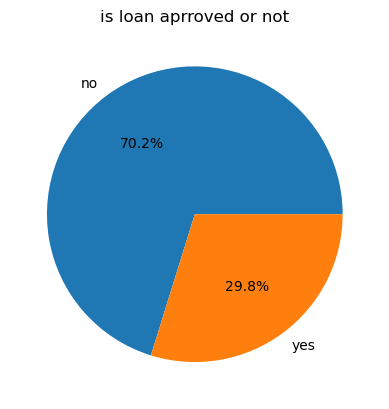

In [15]:
plt.pie(counts,labels=["no","yes"],autopct="%1.1f%%")
plt.title("is loan aprroved or not")
# by this we can see majority applicants does'nt get loan 

<Axes: xlabel='Gender', ylabel='count'>

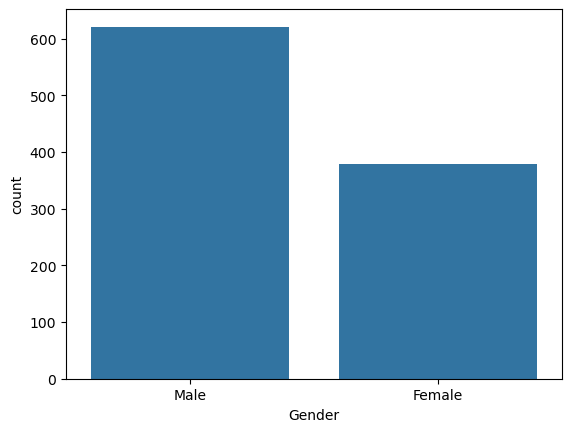

In [16]:

counts = df["Gender"].value_counts()
sns.barplot(counts)
    

<Axes: xlabel='Applicant_Income', ylabel='Count'>

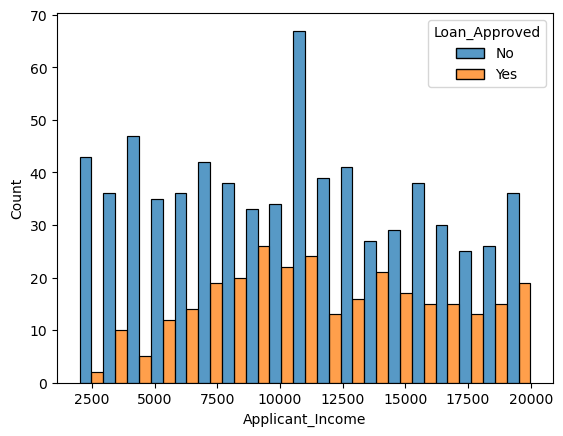

In [17]:
sns.histplot(
    data = df,
    x="Applicant_Income",
    hue = "Loan_Approved",
    bins = 19,
    multiple = "dodge"
)
#  by this we can get a innsight that for high earning applicant loan approval rate is more 

<Axes: xlabel='Loan_Amount', ylabel='Count'>

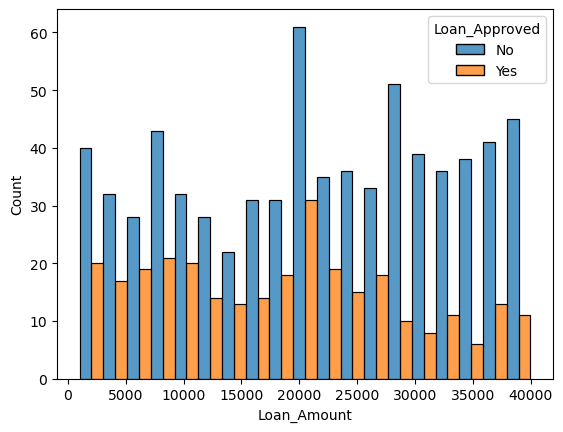

In [18]:
sns.histplot(
    data = df,
    x="Loan_Amount",
    hue = "Loan_Approved",
    bins = 19,
    multiple = "dodge"
)
#  by this we can get a insight that  for high amount loan , loan appproval rate is low 

<Axes: xlabel='Employment_Status', ylabel='Count'>

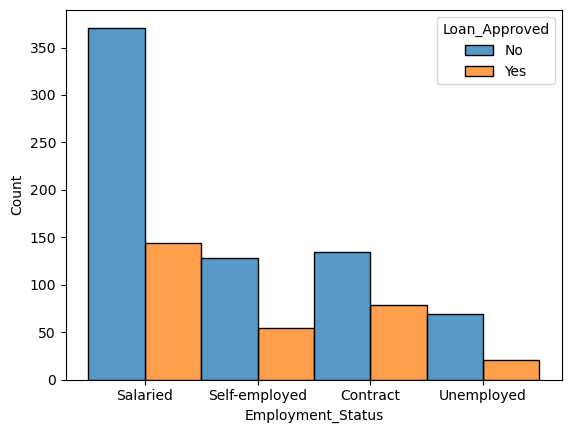

In [19]:
sns.histplot(
    data = df,
    x="Employment_Status",
    hue = "Loan_Approved",
    bins = 19,
    multiple = "dodge"
)
#  for salaried persons loan approval rate is more

<Axes: xlabel='DTI_Ratio', ylabel='Count'>

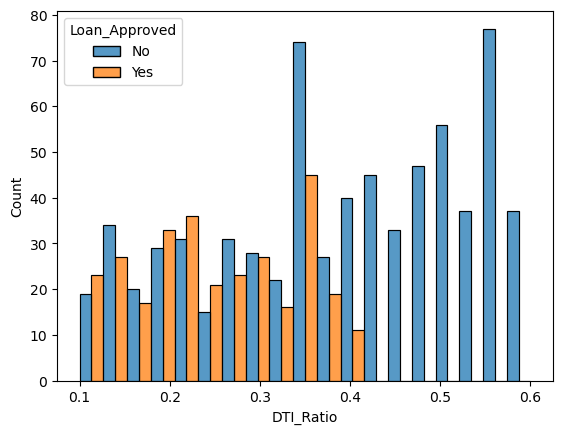

In [20]:

sns.histplot(
    data = df,
    x="DTI_Ratio",
    hue = "Loan_Approved",
    bins = 19,
    multiple = "dodge"
)
# when DTI ratio is low approval rate is high

<Axes: xlabel='Education_Level', ylabel='Count'>

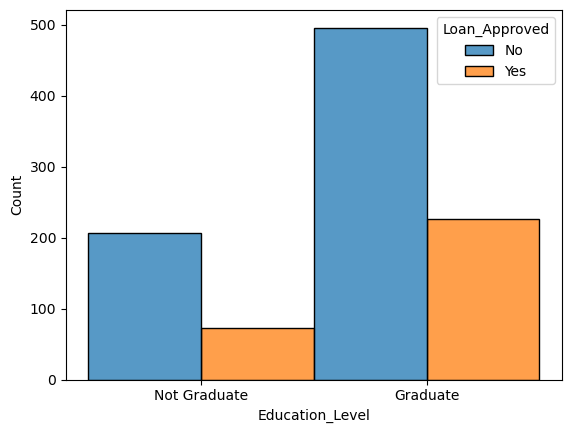

In [21]:
sns.histplot(
    data = df,
    x="Education_Level",
    hue = "Loan_Approved",
    bins = 19,
    multiple = "dodge"
)
#  loan are more likeky to approved for  graduate applicants

<Axes: xlabel='Credit_Score', ylabel='Count'>

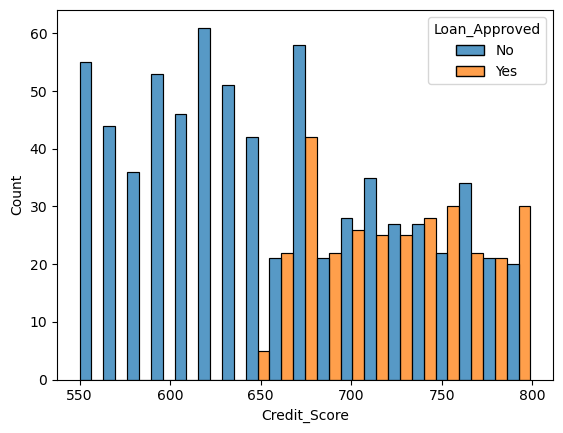

In [22]:
sns.histplot(
    data = df,
    x="Credit_Score",
    hue = "Loan_Approved",
    bins = 19,
    multiple = "dodge"
)
#  when credit scre is more approval rate is high 

# All the insights we get are as 
   -> majority applicants does'nt get loan 
   -> for high earning applicant loan approval rate is more 
   -> for high amount loan , loan appproval rate is low 
   -> for salaried persons loan approval rate is more
   -> when DTI ratio is low approval rate is high
   -> loan are more likeky to approved for  graduate applicants
   -> when credit scre is more approval rate is high

# Now we are going to encode our data

In [23]:
#  in scikit learn we have 2 types of encoder 
   # 1. Label Encoder -> helps to encode features into same column and this does'nt make ant new columns 
   # 2. one hot encoder -> this func. makes several colums according to categories and returns a 2d array of result encoding 
from sklearn.preprocessing import LabelEncoder , OneHotEncoder

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_Income    1000 non-null   float64
 1   Coapplicant_Income  1000 non-null   float64
 2   Employment_Status   1000 non-null   object 
 3   Age                 1000 non-null   float64
 4   Marital_Status      1000 non-null   object 
 5   Dependents          1000 non-null   float64
 6   Credit_Score        1000 non-null   float64
 7   Existing_Loans      1000 non-null   float64
 8   DTI_Ratio           1000 non-null   float64
 9   Savings             1000 non-null   float64
 10  Collateral_Value    1000 non-null   float64
 11  Loan_Amount         1000 non-null   float64
 12  Loan_Term           1000 non-null   float64
 13  Loan_Purpose        1000 non-null   object 
 14  Property_Area       1000 non-null   object 
 15  Education_Level     1000 non-null   object 
 16  Gender 

In [25]:

One_Hot_encod_cols = [ "Marital_Status" , "Loan_Purpose" , "Property_Area" , "Gender" ,"Employer_Category"]

In [26]:
lab_encoder = LabelEncoder()

In [27]:
df["Loan_Approved"] = lab_encoder.fit_transform(df["Loan_Approved"])

In [28]:
df["Education_Level"] = lab_encoder.fit_transform(df["Education_Level"])
df["Employment_Status"] = lab_encoder.fit_transform(df["Employment_Status"])


In [29]:
df

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.000000,1387.0,1,51.0,Married,0.0,637.0,4.0,0.53,19403.000000,45638.0,16619.0,84.0,Personal,Urban,1,Female,Private,0
1,2860.000000,2679.0,1,46.0,Married,3.0,621.0,2.0,0.30,2580.000000,49272.0,38687.0,48.0,Car,Semiurban,0,Male,Private,0
2,7390.000000,2106.0,1,25.0,Single,2.0,674.0,4.0,0.20,13844.000000,6908.0,27943.0,72.0,Business,Urban,0,Female,Government,1
3,13964.000000,8173.0,1,40.0,Married,2.0,579.0,3.0,0.31,9553.000000,10844.0,27819.0,60.0,Business,Rural,0,Female,Government,0
4,13284.000000,4223.0,2,31.0,Single,2.0,721.0,1.0,0.29,9386.000000,37629.0,12741.0,72.0,Car,Urban,0,Male,Private,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,10852.571579,9092.0,1,58.0,Married,0.0,557.0,0.0,0.59,5370.000000,43563.0,8311.0,72.0,Personal,Urban,1,Male,Unemployed,0
996,3279.000000,6356.0,2,58.0,Married,1.0,646.0,3.0,0.19,9940.452632,18361.0,22563.0,12.0,Business,Urban,0,Female,Government,0
997,15192.000000,8433.0,0,48.0,Single,1.0,666.0,1.0,0.40,8581.000000,41335.0,16203.0,24.0,Home,Rural,0,Male,MNC,0
998,9083.000000,7380.0,3,50.0,Single,1.0,748.0,3.0,0.31,13491.000000,8933.0,10290.0,36.0,Personal,Urban,0,Male,Private,1


In [30]:
#  now lets do one hot encoding 
ohe = OneHotEncoder(drop="first" , handle_unknown="ignore", sparse_output=False)

In [31]:
encoded = ohe.fit_transform(df[One_Hot_encod_cols])

In [32]:
encoded

array([[0., 0., 0., ..., 0., 1., 0.],
       [0., 1., 0., ..., 0., 1., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [1., 0., 0., ..., 1., 0., 0.],
       [1., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 0., 1., 0.]], shape=(1000, 12))

In [33]:
encoded_df = pd.DataFrame(encoded,columns = ohe.get_feature_names_out(One_Hot_encod_cols),index=df.index)

In [34]:
encoded_df

,Marital_Status_Single,Loan_Purpose_Car,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
2,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
995,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
996,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
997,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
998,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0


In [35]:
 #  now we have to concatenate our encoded df into original data
df = pd.concat([df.drop(columns = One_Hot_encod_cols) , encoded_df],axis =1)

In [36]:
df

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,...,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
0,17795.000000,1387.0,1,51.0,0.0,637.0,4.0,0.53,19403.000000,45638.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,2860.000000,2679.0,1,46.0,3.0,621.0,2.0,0.30,2580.000000,49272.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
2,7390.000000,2106.0,1,25.0,2.0,674.0,4.0,0.20,13844.000000,6908.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
3,13964.000000,8173.0,1,40.0,2.0,579.0,3.0,0.31,9553.000000,10844.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,13284.000000,4223.0,2,31.0,2.0,721.0,1.0,0.29,9386.000000,37629.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,10852.571579,9092.0,1,58.0,0.0,557.0,0.0,0.59,5370.000000,43563.0,...,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
996,3279.000000,6356.0,2,58.0,1.0,646.0,3.0,0.19,9940.452632,18361.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
997,15192.000000,8433.0,0,48.0,1.0,666.0,1.0,0.40,8581.000000,41335.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
998,9083.000000,7380.0,3,50.0,1.0,748.0,3.0,0.31,13491.000000,8933.0,...,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0


# Now lets see its Corelation HeatMap

In [37]:
num_cols = df.select_dtypes("number")
corr_mat = num_cols.corr()

In [38]:
corr_mat

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,...,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
Applicant_Income,1.000000,0.007545,0.005975,-0.023988,-0.026658,-0.009818,-0.010457,-0.009107,-0.028358,0.018789,...,0.032794,0.074209,-0.031234,0.004845,-0.036260,-0.020871,-0.025011,0.102589,-0.044639,-0.011995
Coapplicant_Income,0.007545,1.000000,0.005859,0.014306,-0.026733,0.058423,0.012418,0.058078,-0.015047,0.009457,...,0.028000,0.016022,0.059549,-0.010058,0.030045,-0.010148,-0.001146,0.037640,0.004312,-0.047929
Employment_Status,0.005975,0.005859,1.000000,-0.020578,0.051529,-0.050434,0.023561,0.001288,0.020023,-0.053255,...,-0.036315,0.008010,0.007568,-0.042253,0.011611,0.001134,0.008444,0.021774,-0.004442,-0.029418
Age,-0.023988,0.014306,-0.020578,1.000000,-0.018767,-0.004212,0.023330,0.007903,-0.000986,0.037382,...,-0.006283,0.029865,0.037293,0.003100,-0.025661,0.048402,-0.066041,0.021232,-0.012960,0.072462
Dependents,-0.026658,-0.026733,0.051529,-0.018767,1.000000,-0.007687,-0.026338,0.011498,-0.004981,0.023004,...,-0.044642,0.027343,-0.005785,-0.032278,0.024082,0.013706,-0.009250,-0.018757,0.030197,-0.054147
Credit_Score,-0.009818,0.058423,-0.050434,-0.004212,-0.007687,1.000000,-0.007130,0.002338,-0.065353,0.007865,...,0.026013,-0.008658,0.015324,-0.006946,0.004445,-0.039739,-0.007076,0.066736,-0.000049,-0.046087
Existing_Loans,-0.010457,0.012418,0.023561,0.023330,-0.026338,-0.007130,1.000000,0.047008,0.034435,-0.049916,...,-0.010035,0.001777,0.023212,-0.053971,0.035629,-0.038762,-0.009642,0.030520,-0.019306,0.045391
DTI_Ratio,-0.009107,0.058078,0.001288,0.007903,0.011498,0.002338,0.047008,1.000000,0.004663,-0.009622,...,0.040432,-0.014125,-0.036648,0.044898,-0.006156,0.009624,-0.007214,0.002090,-0.003506,0.026018
Savings,-0.028358,-0.015047,0.020023,-0.000986,-0.004981,-0.065353,0.034435,0.004663,1.000000,0.015481,...,0.032558,-0.012217,-0.028948,0.005438,0.016833,-0.006667,-0.011683,0.004381,-0.030208,0.027178
Collateral_Value,0.018789,0.009457,-0.053255,0.037382,0.023004,0.007865,-0.049916,-0.009622,0.015481,1.000000,...,0.040406,-0.050975,-0.007120,0.020061,0.007975,0.000897,0.035760,-0.013464,-0.014480,-0.009655


<Axes: >

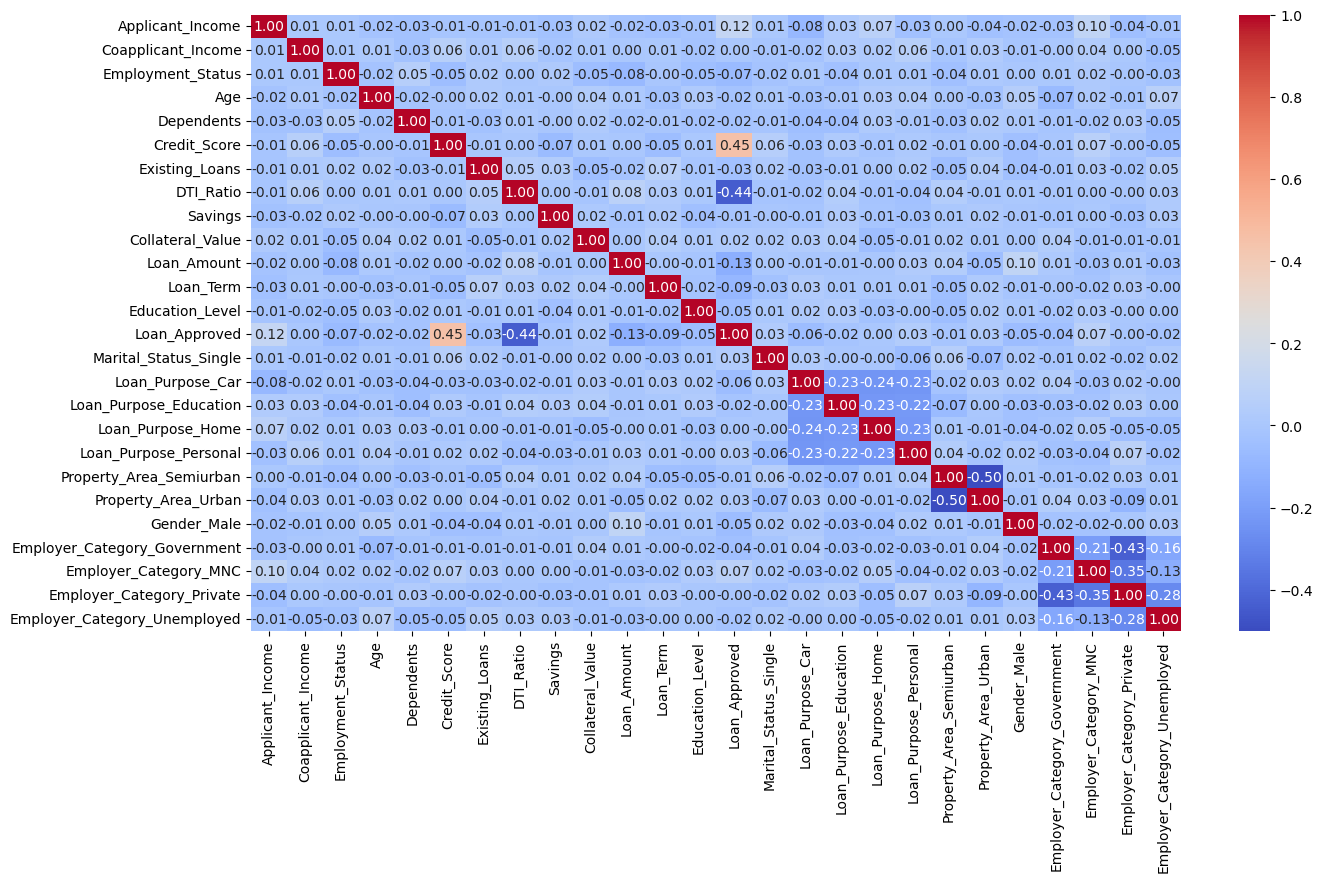

In [39]:
plt.figure(figsize=(15,8))
sns.heatmap(
    corr_mat,
    annot = True,
    fmt = ".2f",
    cmap = "coolwarm",
    
)

# now we fully encodes our data --> let's start model training


In [40]:
from sklearn.model_selection import train_test_split
x = df.drop("Loan_Approved" , axis =1)
y = df["Loan_Approved"]

In [41]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

In [45]:
#  Feature Scaling 
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [47]:
#  we are going to train and eval;uate 3 models 
#  1. Naive Bayes         2. logistic regression                3. KNN 


#  Logistic Regresion
from sklearn.linear_model import LogisticRegression
Logistic_model = LogisticRegression()

Logistic_model.fit(X_train,y_train)




,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [48]:
y_pred_logistic = Logistic_model.predict(X_test)

In [51]:
# Eva;uation step ---> Evaluating Logistic Model
import numpy as np
from sklearn.metrics import accuracy_score
from sklearn.metrics import recall_score
from sklearn.metrics import precision_score


pre = precision_score(y_test, y_pred_logistic, average='macro', zero_division=np.nan)
acc = accuracy_score(y_test, y_pred_logistic)
rec = recall_score(y_test, y_pred_logistic , average='macro')

print("Precesion Score is : " , pre)
print("Accuracy Score is : " , acc)
print("Recall Score is : " , rec)

Precesion Score is :  0.8093735390369332
Accuracy Score is :  0.835
Recall Score is :  0.8066852044954235


In [52]:
# Model 2 --> KNN 
from sklearn.neighbors import KNeighborsClassifier
KNN_model = KNeighborsClassifier()
KNN_model.fit(X_train,y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [53]:
y_pred_KNN = KNN_model.predict(X_test)

In [54]:
#  Evaluating For KNN Model 
pre = precision_score(y_test, y_pred_KNN, average='macro', zero_division=np.nan)
acc = accuracy_score(y_test, y_pred_KNN)
rec = recall_score(y_test, y_pred_KNN , average='macro')

print("Precesion Score is : " , pre)
print("Accuracy Score is : " , acc)
print("Recall Score is : " , rec)

Precesion Score is :  0.702962577962578
Accuracy Score is :  0.745
Recall Score is :  0.6809755532383269


In [56]:
#  MOdel 3 --> Naive Bayes 
from sklearn.naive_bayes import GaussianNB
NB_model = GaussianNB()
NB_model

,priors,None
,var_smoothing,1e-09


In [57]:
NB_model.fit(X_train , y_train)

,priors,None
,var_smoothing,1e-09


In [58]:
y_pred_NB = NB_model.predict(X_test)

In [59]:
pre = precision_score(y_test, y_pred_NB, average='macro', zero_division=np.nan)
acc = accuracy_score(y_test, y_pred_NB)
rec = recall_score(y_test, y_pred_NB , average='macro')

print("Precesion Score is : " , pre)
print("Accuracy Score is : " , acc)
print("Recall Score is : " , rec)

Precesion Score is :  0.8423389142567225
Accuracy Score is :  0.855
Recall Score is :  0.8127099988413857
